# Access Sentinel-1 in Analysis Mode

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-1** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage.

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).
For an example of the native mode, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

## Main Features of the Analysis Mode for Sentinel-1

The current Sentinel-1 analysis workflow covers [**GRD products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd?.language=en).

Sentinel-1 GRD data is provided in radar geometry, defined by the coordinates (`azimuth_time`, `ground_range`). To transform this data into an **analysis-ready dataset**, several processing steps are required:

1. **Radiometric Calibration:** Raw pixel values (DN) are converted into physically meaningful backscatter values using the `beta_nought` calibration lookup table (LUT).
2. **Geometric Terrain Correction (GTC):** Using a Digital Elevation Model (DEM), the processor performs **inverse geocoding** by solving the zero-Doppler equation based on satellite orbit information and terrain elevation. This step maps the data from radar geometry to a georeferenced grid.
3. **Radiometric Terrain Correction (RTC):** RTC compensates for terrain-induced radiometric distortions such as foreshortening, layover, and slope-dependent brightness variations.

**References**

📖 [D. Small, *Flattening Gamma: Radiometric Terrain Correction for SAR Imagery*](https://ieeexplore.ieee.org/document/5752845)


### Key properties of Sentinel-1 analysis mode

- **Default mode** for the `"eopf-zarr"` backend
- **Flexible target grid definition**
  - Provide a DEM directly via the `dem` parameter (`xarray.DataArray`)
  - Or define the grid using `resolution`, `crs`, and `bbox`
  - If no DEM is provided, the
    [CopDEM COG (30 m)](https://browser.stac.dataspace.copernicus.eu/collections/cop-dem-glo-30-dged-cog)
    is automatically retrieved via the CDSE STAC API, which requires [CDSE S3 credentials](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets)
- **Radiometric Terrain Correction (RTC)** can be disabled using `apply_rtc=False`
- **Configurable interpolation:** controlled via `interp_methods`; supported methods: `nearest`, `bilinear`
- **Flexible variable selection:** select variables by explicit names or regex patterns
- **Footprint scaling:** controlled via `footprint_scale_factor`; defines how radar pixels contribute to the output grid; default: `(3.0, 3.0)` which accounts for resolution differences (e.g., ~10 m GRD vs. ~30 m DEM).


For full details on opening parameters, see the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode) and, specifically for Sentinel-1, the [Sentinel-1 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1).

---

## Import Modules

The `eopf-zarr` backend is registered as an `xarray` plugin. Import `xarray` as usual, plus helper libraries used in this notebook.


In [1]:
import os

import pystac_client
import xarray as xr
from xcube_resampling.utils import reproject_bbox

---

## Open a Sentinel-1 GRD Product in Analysis Mode

We begin with an example that accesses a Sentinel-1 GRD product in **analysis mode**.


### Find a Sentinel-1 GRD Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) to search for a Sentinel-1 GRD tile.

In [2]:
bbox = [5.3, 43.1, 5.8, 43.4]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2026-04-16", "2026-04-16"],
    ).items()
)
items

[<Item id=S1A_IW_GRDH_1SDV_20260416T173048_20260416T173113_064108_08114E_92D0>]

In [3]:
item = items[0]

### Open Sentinel-1 GRD with default parameters

We can now open the Sentinel-1 product in **analysis mode**. Since this is the default, the `op_mode` parameter does not need to be specified.

The following cell returns a **lazy dataset**. For demonstration purposes, we restrict the data to a small spatial subset by specifying a bounding box.

Before proceeding, CDSE S3 credentials must be configured to enable access to the CopDEM (30 m) dataset from CDSE. Instructions for generating credentials are available [here](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets).

In [4]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": "xxx",
        "AWS_SECRET_ACCESS_KEY": "xxx",
    }
)

In [5]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    chunks={}
)
ds

<xarray.Dataset> Size: 78MB
Dimensions:       (lat: 1081, lon: 1801)
Coordinates:
  * lat           (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon           (lon) float64 14kB 5.3 5.3 5.301 5.301 ... 5.799 5.799 5.8 5.8
    pixel         (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    azimuth_time  (lat, lon) datetime64[ns] 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    ground_range  (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vh            (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    vv            (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
Attributes: (3)

As an example, we plot the calibrated VV polarization band. Plotting triggers lazy loading and computation.

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


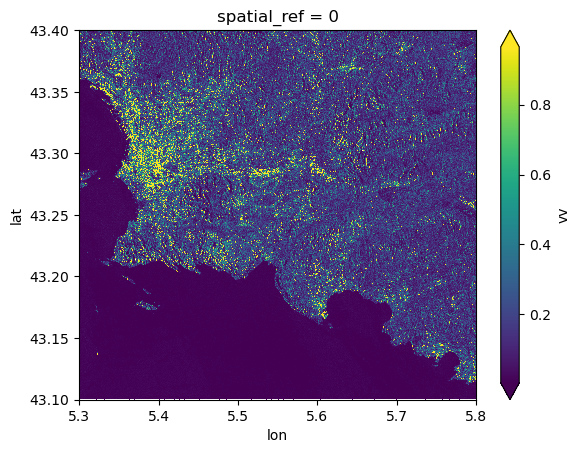

In [6]:
ds.vv.plot(robust=True)

### Open Sentinel-1 GRD in UTM grid

In the following we show different ways to open a Sentinel-1 GRD product in analysis mode.

We can define the target gridmapping in UTM using the `resolution`, `crs`,and `bbox` parameters.


In [7]:
crs_utm = "EPSG:32631"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", "EPSG:32631")

ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox_utm,
    crs=crs_utm,
    resolution=30, # meters
    chunks={}
)
ds

<xarray.Dataset> Size: 64MB
Dimensions:       (lat: 1152, lon: 1387)
Coordinates:
  * lat           (lat) float64 9kB 4.809e+06 4.809e+06 ... 4.775e+06 4.775e+06
  * lon           (lon) float64 11kB 6.863e+05 6.863e+05 ... 7.278e+05 7.278e+05
    pixel         (lat, lon) float64 13MB dask.array<chunksize=(1152, 1387), meta=np.ndarray>
    azimuth_time  (lat, lon) datetime64[ns] 13MB dask.array<chunksize=(1152, 1387), meta=np.ndarray>
    ground_range  (lat, lon) float64 13MB dask.array<chunksize=(1152, 1387), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vh            (lat, lon) float64 13MB dask.array<chunksize=(1152, 1387), meta=np.ndarray>
    vv            (lat, lon) float64 13MB dask.array<chunksize=(1152, 1387), meta=np.ndarray>
Attributes: (3)

We can again visualize one polarization channel (for example `vv`).

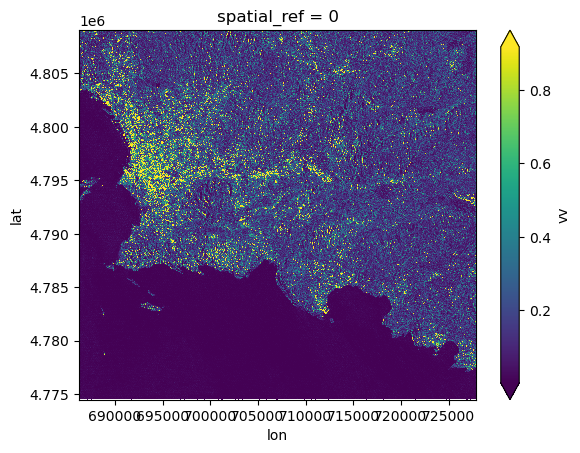

In [8]:
ds.vv.plot(robust=True)

### Turn off radiometric terrain correction (RTC)

In the next example we turn off the RTC and select on the vv band.

In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    variables=["vv"],
    apply_rtc=False,
    chunks={}
)
ds

<xarray.Dataset> Size: 55MB
Dimensions:       (lat: 1081, lon: 1801)
Coordinates:
  * lat           (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon           (lon) float64 14kB 5.3 5.3 5.301 5.301 ... 5.799 5.799 5.8 5.8
    pixel         (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    azimuth_time  (lat, lon) datetime64[ns] 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    ground_range  (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vv            (lat, lon) float32 8MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
Attributes: (3)

In the following plot you can clearly see the structure of the mountainous terrain, since the backscatter variation has not been corrected for the terrain.

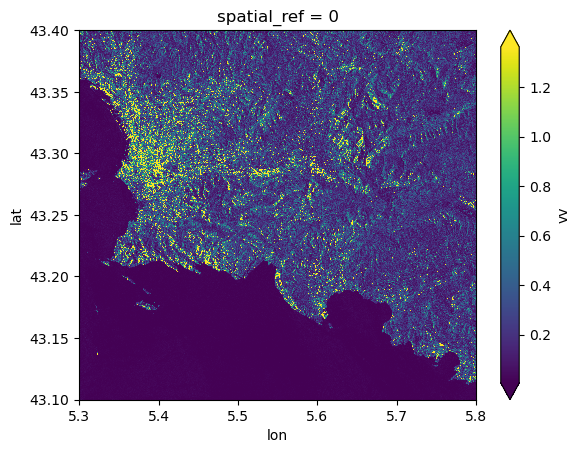

In [10]:
ds.vv.plot(robust=True)

### Interpolation Method: Nearest Neighbor

In the next example, we set the interpolation method to `nearest`, which is applied during both Geometric Terrain Correction (GTC) and Radiometric Terrain Correction (RTC).

This approach improves computational performance but reduces accuracy compared to bilinear interpolation, as it avoids spatial smoothing and instead assigns the value of the closest pixel.

In [11]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    interp_methods="nearest",
    chunks={}
)
ds

<xarray.Dataset> Size: 78MB
Dimensions:       (lat: 1081, lon: 1801)
Coordinates:
  * lat           (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon           (lon) float64 14kB 5.3 5.3 5.301 5.301 ... 5.799 5.799 5.8 5.8
    pixel         (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    azimuth_time  (lat, lon) datetime64[ns] 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    ground_range  (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vh            (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
    vv            (lat, lon) float64 16MB dask.array<chunksize=(1081, 1801), meta=np.ndarray>
Attributes: (3)

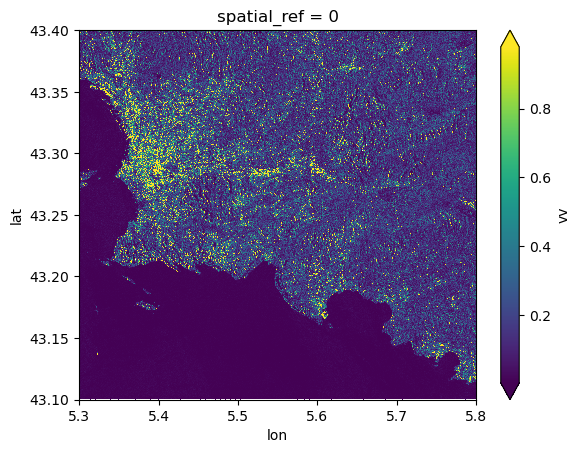

In [12]:
ds.vv.plot(robust=True)

## Conclusion

This notebook demonstrates how to access Sentinel-1 EOPF Zarr samples in **analysis mode** using the **xarray-eopf** plugin. The key takeaways are:

- **Analysis mode** is the default `op_mode` and does not need to be explicitly specified.
- The analysis workflow combines:
  - **Radiometric calibration** using LUTs
  - **Geometric Terrain Correction (GTC)** via inverse geocoding using orbit information and a DEM
  - Optional **Radiometric Terrain Correction (RTC)** to reduce terrain-induced radiometric distortions
- A DEM can be:
  - explicitly provided by the user, or
  - automatically retrieved from the CDSE STAC API
- Data is accessed lazily and processed at a **user-defined resolution, bounding box, and CRS**, enabling flexible subsetting, resampling, and reprojection.
  - When a DEM is provided, the output grid is derived directly from the DEM grid definition.

> **Note:** This notebook only covers **analysis mode** for Sentinel-1. To learn more about **native mode**, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).


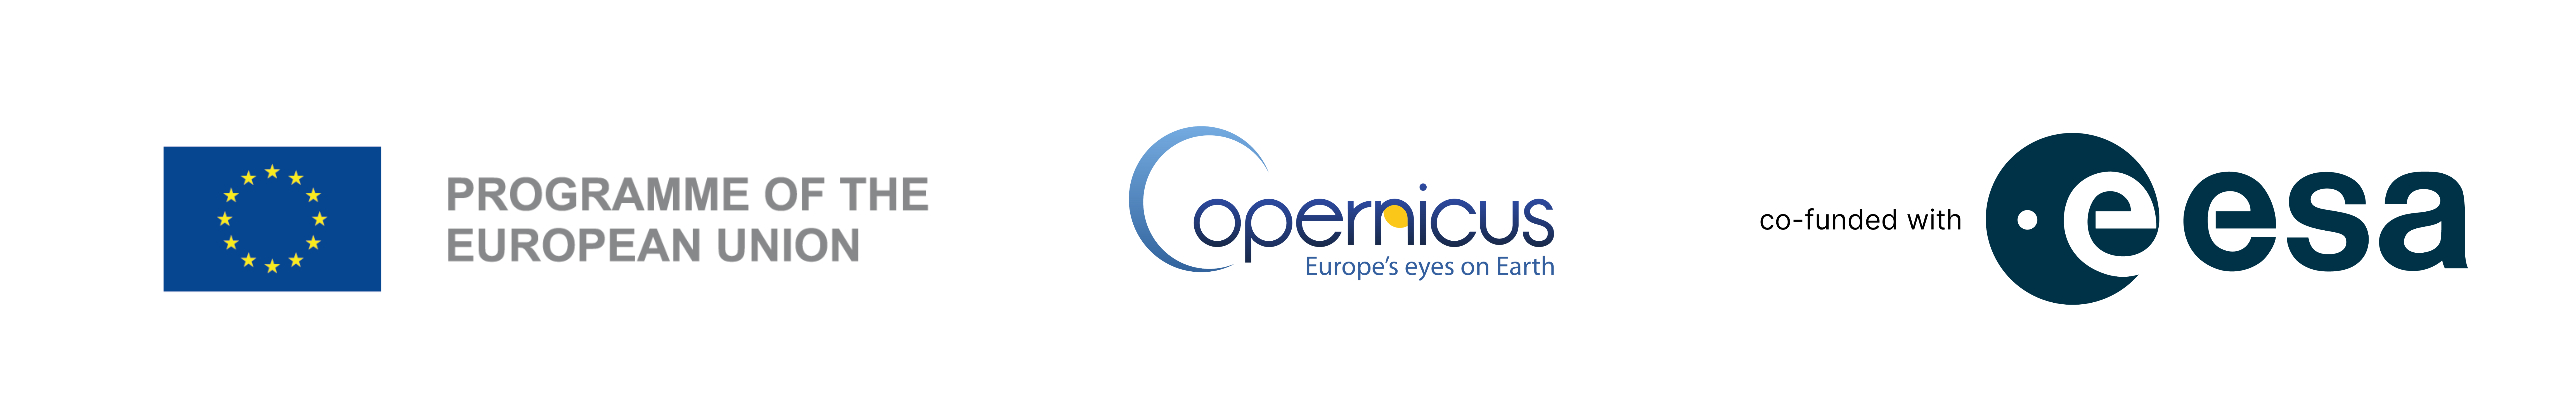